In [ ]:
# 6CS012 - Tutorial 03
# Perceptron Learning Algorithm
#Samrat Bam 


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)

In [3]:
#Step 1: Define Perceptron Class

class Perceptron:
    def __init__(self, input_size, learning_rate=0.1, epochs=10):
        """
        Initializes the perceptron with small random weights.

        Parameters:
        input_size : int
            Number of input features
        learning_rate : float
            Step size for weight update
        epochs : int
            Number of passes over dataset
        """
        # +1 for bias weight
        self.weights = np.random.randn(input_size + 1) * 0.2 - 0.1
        self.learning_rate = learning_rate
        self.epochs = epochs

    def step_function(self, z):
        """
        Step activation function.
        Returns 1 if z >= 0, else 0
        """
        return 1 if z >= 0 else 0

    def predict(self, x):
        """
        Predict output for one sample
        """
        x = np.insert(x, 0, 1)   # add bias input = 1
        z = np.dot(self.weights, x)
        return self.step_function(z)

    def train(self, X, y):
        """
        Train perceptron using perceptron learning rule
        """
        X = np.c_[np.ones((X.shape[0], 1)), X]  # add bias column

        for epoch in range(self.epochs):
            total_errors = 0
            print(f"\nEpoch {epoch+1}")
            print("-" * 40)

            for i in range(X.shape[0]):
                z = np.dot(self.weights, X[i])
                y_pred = self.step_function(z)
                error = y[i] - y_pred

                if error != 0:
                    self.weights = self.weights + self.learning_rate * error * X[i]
                    total_errors += 1

                print(f"Input: {X[i][1:]}, Target: {y[i]}, Predicted: {y_pred}, Error: {error}, Weights: {self.weights}")

            if total_errors == 0:
                print("\nPerceptron converged early.")
                break

        print("\nFinal weights:", self.weights)

In [4]:
#Step 2: OR Gate Dataset
X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_or = np.array([0, 1, 1, 1])

print("OR Input:\n", X_or)
print("OR Target:\n", y_or)

OR Input:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
OR Target:
 [0 1 1 1]



Epoch 1
----------------------------------------
Input: [0. 0.], Target: 0, Predicted: 0, Error: 0, Weights: [-0.00065717 -0.12765286  0.02953771]
Input: [0. 1.], Target: 1, Predicted: 1, Error: 0, Weights: [-0.00065717 -0.12765286  0.02953771]
Input: [1. 0.], Target: 1, Predicted: 0, Error: 1, Weights: [ 0.09934283 -0.02765286  0.02953771]
Input: [1. 1.], Target: 1, Predicted: 1, Error: 0, Weights: [ 0.09934283 -0.02765286  0.02953771]

Epoch 2
----------------------------------------
Input: [0. 0.], Target: 0, Predicted: 1, Error: -1, Weights: [-0.00065717 -0.02765286  0.02953771]
Input: [0. 1.], Target: 1, Predicted: 1, Error: 0, Weights: [-0.00065717 -0.02765286  0.02953771]
Input: [1. 0.], Target: 1, Predicted: 0, Error: 1, Weights: [0.09934283 0.07234714 0.02953771]
Input: [1. 1.], Target: 1, Predicted: 1, Error: 0, Weights: [0.09934283 0.07234714 0.02953771]

Epoch 3
----------------------------------------
Input: [0. 0.], Target: 0, Predicted: 1, Error: -1, Weights: [-0.000657

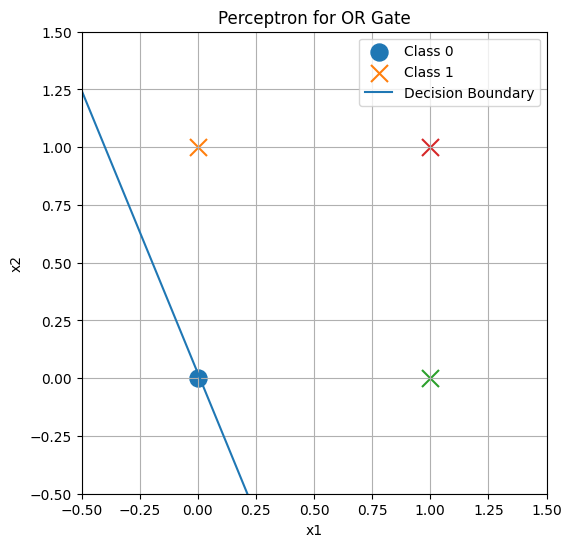

In [5]:
#Step 3: Train Perceptron for OR
perceptron_or = Perceptron(input_size=2, learning_rate=0.1, epochs=10)
perceptron_or.train(X_or, y_or)

# Step 4: Test OR Predictions
print("\nTesting OR Gate:")
for x in X_or:
    pred = perceptron_or.predict(x)
    print(f"Input: {x}, Predicted Output: {pred}")

# Step 5: Plot OR Data Points


plt.figure(figsize=(6,6))

for i in range(len(X_or)):
    if y_or[i] == 0:
        plt.scatter(X_or[i,0], X_or[i,1], marker='o', s=150, label='Class 0' if i == 0 else "")
    else:
        plt.scatter(X_or[i,0], X_or[i,1], marker='x', s=150, label='Class 1' if i == 1 else "")

# decision boundary: w0 + w1*x1 + w2*x2 = 0
w = perceptron_or.weights
x_vals = np.linspace(-0.5, 1.5, 100)

if abs(w[2]) > 1e-6:
    y_vals = -(w[0] + w[1]*x_vals) / w[2]
    plt.plot(x_vals, y_vals, label='Decision Boundary')

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron for OR Gate")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
# Step 6: XOR Gate Dataset


X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = np.array([0, 1, 1, 0])

print("XOR Input:\n", X_xor)
print("XOR Target:\n", y_xor)

XOR Input:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
XOR Target:
 [0 1 1 0]


In [7]:
# Step 7: Train Single Perceptron for XOR


perceptron_xor = Perceptron(input_size=2, learning_rate=0.1, epochs=20)
perceptron_xor.train(X_xor, y_xor)

# Step 8: Test XOR Predictions


print("\nTesting XOR Gate:")
for x in X_xor:
    pred = perceptron_xor.predict(x)
    print(f"Input: {x}, Predicted Output: {pred}")



Epoch 1
----------------------------------------
Input: [0. 0.], Target: 0, Predicted: 1, Error: -1, Weights: [ 0.10460597 -0.14683067 -0.14682739]
Input: [0. 1.], Target: 1, Predicted: 0, Error: 1, Weights: [ 0.20460597 -0.14683067 -0.04682739]
Input: [1. 0.], Target: 1, Predicted: 1, Error: 0, Weights: [ 0.20460597 -0.14683067 -0.04682739]
Input: [1. 1.], Target: 0, Predicted: 1, Error: -1, Weights: [ 0.10460597 -0.24683067 -0.14682739]

Epoch 2
----------------------------------------
Input: [0. 0.], Target: 0, Predicted: 1, Error: -1, Weights: [ 0.00460597 -0.24683067 -0.14682739]
Input: [0. 1.], Target: 1, Predicted: 0, Error: 1, Weights: [ 0.10460597 -0.24683067 -0.04682739]
Input: [1. 0.], Target: 1, Predicted: 0, Error: 1, Weights: [ 0.20460597 -0.14683067 -0.04682739]
Input: [1. 1.], Target: 0, Predicted: 1, Error: -1, Weights: [ 0.10460597 -0.24683067 -0.14682739]

Epoch 3
----------------------------------------
Input: [0. 0.], Target: 0, Predicted: 1, Error: -1, Weights: [

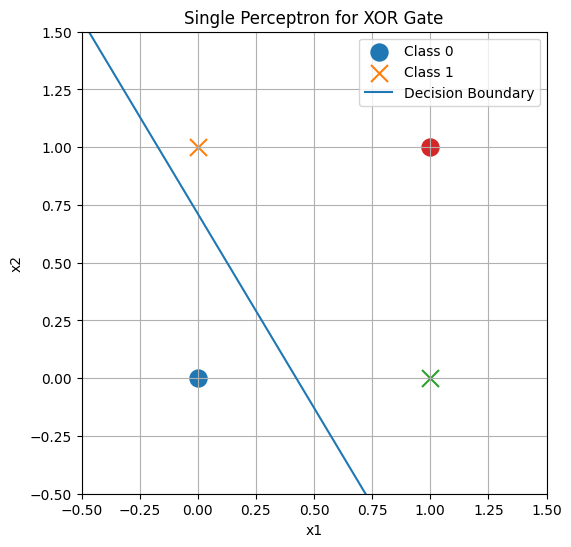


Conclusion:
1. Perceptron successfully learns OR gate.
2. Single perceptron fails for XOR gate.
3. XOR is not linearly separable.
4. XOR needs multilayer perceptron (MLP).


In [8]:
# Step 9: Plot XOR Data Points


plt.figure(figsize=(6,6))

for i in range(len(X_xor)):
    if y_xor[i] == 0:
        plt.scatter(X_xor[i,0], X_xor[i,1], marker='o', s=150, label='Class 0' if i == 0 else "")
    else:
        plt.scatter(X_xor[i,0], X_xor[i,1], marker='x', s=150, label='Class 1' if i == 1 else "")

w = perceptron_xor.weights
x_vals = np.linspace(-0.5, 1.5, 100)

if abs(w[2]) > 1e-6:
    y_vals = -(w[0] + w[1]*x_vals) / w[2]
    plt.plot(x_vals, y_vals, label='Decision Boundary')

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Single Perceptron for XOR Gate")
plt.grid(True)
plt.legend()
plt.show()

# Step 10: Simple Conclusion Print

print("\nConclusion:")
print("1. Perceptron successfully learns OR gate.")
print("2. Single perceptron fails for XOR gate.")
print("3. XOR is not linearly separable.")
print("4. XOR needs multilayer perceptron (MLP).")